# Ví dụ 1 — Crammer–Singer SVM (Linear) — Dual QP (CVXOPT) **ĐÃ SỬA**
**Sửa chính:** đưa mọi ràng buộc bất đẳng thức vào (G, h); **không** dùng (A, b) cho ràng buộc ≤.
**Tuỳ chọn bias:** bật/tắt bằng biến `USE_BIAS`.

## 0) Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
solvers.options['show_progress'] = False

## 1) Sinh dữ liệu (3 lớp × 100 mẫu)

In [ ]:
np.random.seed(0)
n_per_class = 100
means = np.array([[0.0, 0.0],[3.0, 3.0],[0.0, 4.0]])
cov = np.array([[0.4, 0.0],[0.0, 0.4]])

X_list, y_list = [], []
for k, mu in enumerate(means):
    Xk = np.random.multivariate_normal(mu, cov, n_per_class)
    yk = np.full(n_per_class, k, dtype=int)
    X_list.append(Xk); y_list.append(yk)

X = np.vstack(X_list); y = np.concatenate(y_list)
n, d0 = X.shape; K = len(np.unique(y))
print("X:", X.shape, "y:", y.shape, "K:", K)

X: (300, 2) y: (300,) K: 3


### Trực quan hoá

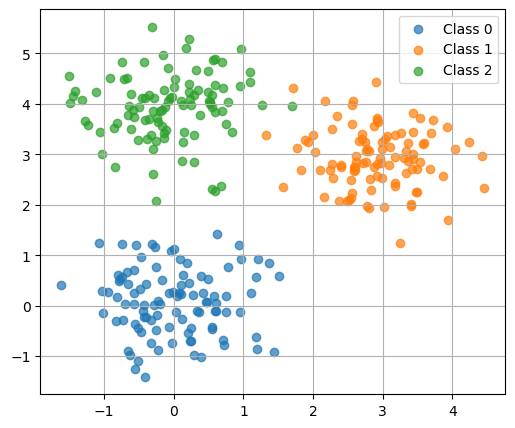

In [ ]:
plt.figure(figsize=(6,5))
for k in range(K):
    plt.scatter(X[y==k,0], X[y==k,1], label=f"Class {k}", alpha=0.7)
plt.legend(); plt.grid(True); plt.show()

## 2) Tuỳ chọn bias

In [ ]:
USE_BIAS = True
if USE_BIAS:
    Xb = np.hstack([X, np.ones((n,1))])
else:
    Xb = X.copy()
n, d = Xb.shape
print("Using bias:", USE_BIAS, "| d =", d)

Using bias: True | d = 3


## 3) Vector hoá biến đối ngẫu

In [ ]:
C = 1.0
pairs = [(i,k) for i in range(n) for k in range(K) if k != y[i]]
m = len(pairs)
print("m =", m, "expected =", n*(K-1))

m = 600 expected = 600


## 4) Lắp đặt P tổng quát (linear, có i≠j)

In [ ]:
# Gram matrix
Gx = Xb @ Xb.T

P = np.zeros((m,m), float)
for p,(i,k) in enumerate(pairs):
    yi = y[i]
    for q,(j,l) in enumerate(pairs):
        yj = y[j]
        val = 0.0
        if yi == yj: val += 1.0
        if yi == l:  val -= 1.0
        if yj == k:  val -= 1.0
        if k == l:   val += 1.0
        P[p,q] = val * Gx[i,j]

q = -np.ones(m)
# Inequalities:
# (1) alpha >= 0  -> -I a <= 0
G1 = -np.eye(m); h1 = np.zeros(m)
# (2) sum_k alpha_{i,k} <= C
Aineq = np.zeros((n,m))
for t,(i,k) in enumerate(pairs):
    Aineq[i,t] = 1.0
G = np.vstack([G1, Aineq])
h = np.concatenate([h1, C*np.ones(n)])

## 5) Giải QP

In [ ]:
sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h))
alpha = np.array(sol['x']).reshape(-1)
print("status:", sol['status'], "| nnz(alpha>1e-8):", (alpha>1e-8).sum())

status: optimal | nnz(alpha>1e-8): 35


## 6) Khôi phục W

In [ ]:
W = np.zeros((K,d))
for t,(i,k) in enumerate(pairs):
    a = alpha[t]
    if a>0:
        W[y[i]] += a*Xb[i]
        W[k]    -= a*Xb[i]
print("W:", W.shape)

W: (3, 3)


## 7) Đánh giá

In [ ]:
def predict(Xin):
    return np.argmax(Xin @ W.T, axis=1)

y_pred = predict(Xb)
print("Accuracy:", accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred, digits=4))

Accuracy: 0.9933333333333333
[[100   0   0]
 [  0  99   1]
 [  0   1  99]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     0.9900    0.9900    0.9900       100
           2     0.9900    0.9900    0.9900       100

    accuracy                         0.9933       300
   macro avg     0.9933    0.9933    0.9933       300
weighted avg     0.9933    0.9933    0.9933       300



## 8) Support vectors (KKT)

In [ ]:
eps=1e-5
sv_vars = np.where(alpha>eps)[0]
sv_pts = np.unique([pairs[t][0] for t in sv_vars])
print("Support vectors:", len(sv_pts))

Support vectors: 22


## 9) Vẽ vùng quyết định

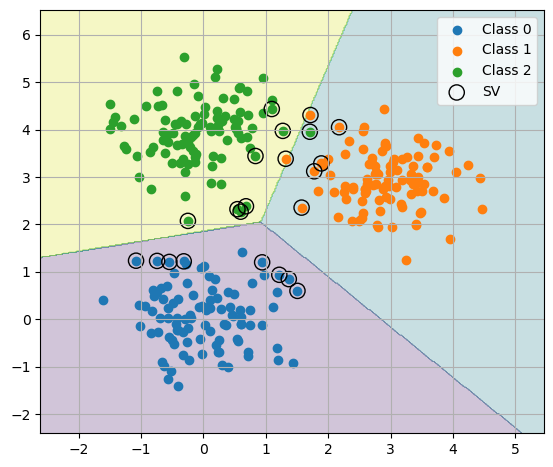

In [ ]:
x1min,x1max = X[:,0].min()-1, X[:,0].max()+1
x2min,x2max = X[:,1].min()-1, X[:,1].max()+1
xx,yy = np.meshgrid(np.linspace(x1min,x1max,400), np.linspace(x2min,x2max,400))
grid = np.c_[xx.ravel(), yy.ravel()]
gridb = np.hstack([grid, np.ones((grid.shape[0],1))]) if USE_BIAS else grid
Z = predict(gridb).reshape(xx.shape)

plt.figure(figsize=(6.5,5.5))
plt.contourf(xx,yy,Z,alpha=0.25)
for k in range(K):
    plt.scatter(X[y==k,0],X[y==k,1],label=f"Class {k}")
plt.scatter(X[sv_pts,0],X[sv_pts,1],s=120,facecolors='none',edgecolors='k',label='SV')
plt.legend(); plt.grid(True); plt.show()